# Lizard Island Research Station Acoustic Data Localization

## Purpose of this Notebook
This notebook analyses the data of hydrophone arrays deployed at Lizard Island Research Station, aiming to localize the detected fish sounds and matching it with videos recorded from the underwater cameras, in hopes of recognizing soniferous fish species' sounds.

We use the localization methods from this notebook: `XAVarrays/localization/Localization_non-linear_inversion.ipynb`. For more information about the methods, please refer to the notebook.

## Library Setup

In [1]:
%pip install ecosound
%pip install ipympl

  Using cached ecosound-0.0.32-py3-none-any.whl.metadata (5.9 kB)
  Using cached xarray-2025.6.1-py3-none-any.whl.metadata (12 kB)
  Using cached dask-2026.7.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pandas-2.3.3-cp310-cp310-macosx_10_9_x86_64.whl.metadata (91 kB)
  Using cached dask_image-2026.5.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached matplotlib-3.10.9-cp310-cp310-macosx_10_12_x86_64.whl.metadata (52 kB)
  Using cached ipympl-0.10.0-py3-none-any.whl.metadata (9.4 kB)
  Using cached scipy-1.15.3-cp310-cp310-macosx_10_13_x86_64.whl.metadata (61 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-macosx_10_9_x86_64.whl.metadata (11 kB)
  Using cached toolz-1.1.0-py3-none-any.whl.metadata (5.1 kB)
  Using cached opencv_python-5.0.0.93-cp310-cp310-macosx_10_16_x86_64.whl
  Using cached soundfile-0.14.0-py2.py3-none-macosx_10_9_x86_64.whl.metadata (18 kB)
  Using cached netcdf4-1.7.4-cp310-cp310-macosx_13_0_x86_64.whl.metadata (2.1 kB)
  Using cached tqdm-4.70.0-py3-none

In [1]:
%matplotlib inline
import pandas as pd
import ecosound.core.tools
from ecosound.core.metadata import DeploymentInfo
import ecosound
import sys
sys.path.append('../localization')
import tools
import detection
import localization

OSError: Could not find/load shared object file

## Define & Load Config Files

### Deployment metadata

In [2]:
# config file
deployment_info_file = r'./config/deployment_info.csv'

# load and display deployment metadata
Deployment = DeploymentInfo()
Deployment.read(deployment_info_file)
Deployment.data

,audio_channel_number,UTC_offset,sampling_frequency,bit_depth,mooring_platform_name,recorder_type,recorder_SN,hydrophone_model,hydrophone_SN,hydrophone_depth,location_name,location_lat,location_lon,location_water_depth,deployment_ID,deployment_date,recovery_date
0,0,10,96000,16,mobile-array,ST4300-HF,5147,HTI-96-Min,1117006,0,LIRS,145.444910,-14.679119,4,LIRS-ROV-20231125-PM,20231125,20231125
1,1,10,96000,16,mobile-array,ST4300-HF,5147,HTI-96-Min,1117005,0,LIRS,-14.679119,145.444910,4,LIRS-ROV-20231125-PM,20231125,20231125
2,2,10,96000,16,mobile-array,ST4300-HF,5147,HTI-96-Min,1117008,0,LIRS,-14.679119,145.444910,4,LIRS-ROV-20231125-PM,20231125,20231125
3,3,10,96000,16,mobile-array,ST4300-HF,5147,HTI-96-Min,1117007,0,LIRS,-14.679119,145.444910,4,LIRS-ROV-20231125-PM,20231125,20231125


### Hydrophone configs

In [3]:
# Define config file
hydrophones_config_file = r'./config/hydrophones_config_LIRS-ROV.csv'

# load and plot hydrophone configuration
hydrophones_config= pd.read_csv(hydrophones_config_file, skipinitialspace=True, dtype={'name': str, 'file_name_root': str}) # load hydrophone coordinates (meters)
hydrophones_config

,name,x,y,z,array_channel,audio_file_channel,data_path,file_name_root
0,Hydrophone 0,0.00,0.8,0.0,3,3,/Users/jasmineyeh/Desktop/WHOI/XAVarrays/lizar...,5147.
1,Hydrophone 1,0.00,0.4,0.5,2,2,/Users/jasmineyeh/Desktop/WHOI/XAVarrays/lizar...,5147.
2,Hydrophone 2,-0.35,0.0,0.0,1,1,/Users/jasmineyeh/Desktop/WHOI/XAVarrays/lizar...,5147.
3,Hydrophone 3,0.35,0.0,0.0,0,0,/Users/jasmineyeh/Desktop/WHOI/XAVarrays/lizar...,5147.


### Detection configs

In [4]:
# Define config files
detection_config_file = r'./config/detection_config_LIRS-ROV.yaml'

# load configuration parameters
detection_config = ecosound.core.tools.read_yaml(detection_config_file)
detection_config

{'AUDIO': {'channel': 3},
 'SPECTROGRAM': {'frame_sec': 0.04266,
  'nfft_sec': 0.04266,
  'step_sec': 0.007,
  'fmin_hz': 100,
  'fmax_hz': 5000,
  'window_type': 'hann',
  'dB': True,
  'use_dask': True,
  'dask_chunks': 100},
 'DENOISER': {'denoiser_name': 'median_equalizer',
  'window_duration_sec': 3,
  'use_dask': True,
  'dask_chunks': [2048, 2000]},
 'DETECTOR': {'detector_name': 'BlobDetector',
  'kernel_duration_sec': 0.01,
  'kernel_bandwidth_hz': 1000,
  'threshold': 20,
  'duration_min_sec': 0.01,
  'bandwidth_min_hz': 500,
  'use_dask': True,
  'dask_chunks': [2048, 2000]}}

### Localization configs

In [5]:
localization_config_file = r'./config/localization_config_LIRS-ROV.yaml'
localization_config = ecosound.core.tools.read_yaml(localization_config_file)
localization_config

{'ENVIRONMENT': {'sound_speed_mps': 1484},
 'TDOA': {'ref_channel': 3,
  'upsample_res_sec': 1e-05,
  'normalize': False,
  'min_corr_val': 0.5,
  'number_freq_bands': 4,
  'min_bandwidth_hz': 200,
  'energy_window_perc': 80},
 'GRIDSEARCH': {'x_limits_m': [-3, 3],
  'y_limits_m': [-3, 3],
  'z_limits_m': [-0.5, 4],
  'spacing_m': 0.02}}

## Hydrohpone Coordinate Calculation
### Theoretical Hydrophone Coordinates
Plot out the hydrophone coordinates given the (x, y, z) data from the hydrophone configuration file. 

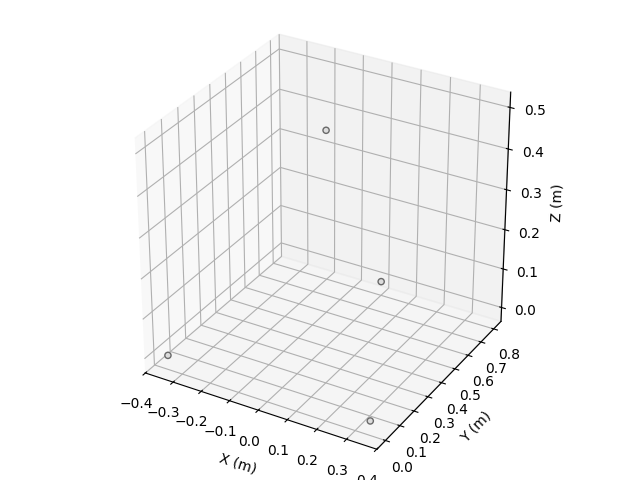

In [6]:
%matplotlib widget
fig, ax = localization.plot_localizations3D(hydrophones=hydrophones_config)

Using matplotlib to plot out the hydrophones' locations, with labeled points and connected lines showing the theoretical model of the deployed hydrophone array.

Distance Matrix:
      A     B     1     2     3     4
A  0.00  0.40  0.80  0.64  0.35  0.35
B  0.40  0.00  0.40  0.50  0.53  0.53
1  0.80  0.40  0.00  0.64  0.87  0.87
2  0.64  0.50  0.64  0.00  0.73  0.73
3  0.35  0.53  0.87  0.73  0.00  0.70
4  0.35  0.53  0.87  0.73  0.70  0.00


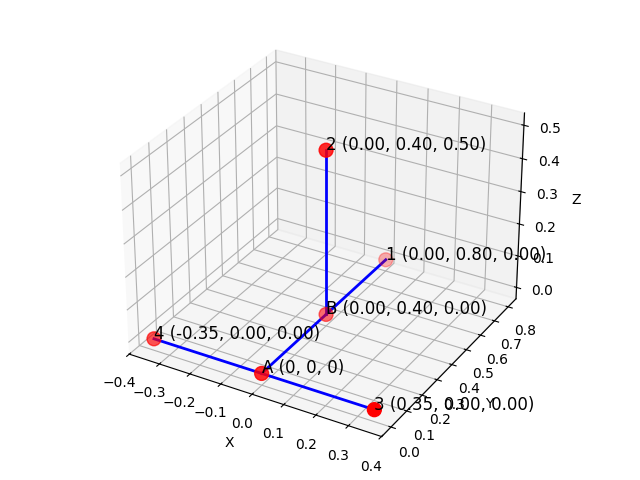

In [7]:
%matplotlib widget
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import numpy as np

# define the six coordinates using integer indexing / slices
defined_coordinates = np.zeros((6, 3))
defined_coordinates[0, :] = [0, 0, 0]
defined_coordinates[1, :] = [0, 0.4, 0]
defined_coordinates[2, :] = [0, 0.8, 0]
defined_coordinates[3, :] = [0, 0.4, 0.5]
defined_coordinates[4, :] = [0.35, 0, 0]
defined_coordinates[5, :] = [-0.35, 0, 0]

# point labels
Points = ['A', 'B', '1', '2', '3', '4']

# calculate the distance matrix
defined_distances = cdist(defined_coordinates, defined_coordinates)
print("Distance Matrix:")
print(pd.DataFrame(defined_distances, index=Points, columns=Points).round(2))

# Create 3D plot
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(defined_coordinates[:, 0], defined_coordinates[:, 1], defined_coordinates[:, 2], color='red', s=100)

# label the points and add the coordinates as text labels
ax.text(defined_coordinates[0, 0], defined_coordinates[0, 1], defined_coordinates[0, 2], 'A (0, 0, 0)', fontsize=12)
ax.text(defined_coordinates[1, 0], defined_coordinates[1, 1], defined_coordinates[1, 2], f'B ({defined_coordinates[1, 0]:.2f}, {defined_coordinates[1, 1]:.2f}, {defined_coordinates[1, 2]:.2f})', fontsize=12)

# the rest of the points (total - 2)
for i, (x, y, z) in enumerate(defined_coordinates):
    if i > 1:
        ax.text(x, y, z, f'{i-1} ({x:.2f}, {y:.2f}, {z:.2f})', fontsize=12)

# add lines in between the points: AB, A3, A4, B1, B2
ax.plot([defined_coordinates[0, 0], defined_coordinates[1, 0]], [defined_coordinates[0, 1], defined_coordinates[1, 1]], [defined_coordinates[0, 2], defined_coordinates[1, 2]], color='blue', linestyle='-', linewidth=2) # line AB
ax.plot([defined_coordinates[0, 0], defined_coordinates[4, 0]], [defined_coordinates[0, 1], defined_coordinates[4, 1]], [defined_coordinates[0, 2], defined_coordinates[4, 2]], color='blue', linestyle='-', linewidth=2) # line A3
ax.plot([defined_coordinates[0, 0], defined_coordinates[5, 0]], [defined_coordinates[0, 1], defined_coordinates[5, 1]], [defined_coordinates[0, 2], defined_coordinates[5, 2]], color='blue', linestyle='-', linewidth=2) # line A4
ax.plot([defined_coordinates[1, 0], defined_coordinates[2, 0]], [defined_coordinates[1, 1], defined_coordinates[2, 1]], [defined_coordinates[1, 2], defined_coordinates[2, 2]], color='blue', linestyle='-', linewidth=2) # line B1
ax.plot([defined_coordinates[1, 0], defined_coordinates[3, 0]], [defined_coordinates[1, 1], defined_coordinates[3, 1]], [defined_coordinates[1, 2], defined_coordinates[3, 2]], color='blue', linestyle='-', linewidth=2) # line B2  

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.tight_layout()

### Caculating practical hydrophone coordinates
We use Multi-dimensional Scaling (MDS) module from scikit-learn to calculate hydrophone coordinates based on given measurements. We input a symmetrical distance matrix that has the distances between each pair of points, set the number of dimension (`n_componenets`), then the calculation result will be the set of solution such that the between-object distances are preserved as well as possible.

In this case, since we have the actual measurements in between each hydrophone and the nodes, we use MDS to calculate the practical hydrophone coordinates, which is different from the theoretical measurements.

For information about the MDS module, please read the [MDS documentation](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.MDS.html).

Total Optimization Stress: 0.0002771403518795683
Coordinates:
[[ 0.05738658  0.18079732 -0.20954078]
 [-0.04661806  0.03018188  0.15428601]
 [-0.15120516 -0.12759837  0.49102998]
 [ 0.02724029 -0.42956821 -0.02198989]
 [-0.28013292  0.1743464  -0.30071242]
 [ 0.39332929  0.17184098 -0.1130729 ]]
Coordinates after normalization (A as origin):
[[ 0.          0.          0.        ]
 [-0.10400464 -0.15061545  0.3638268 ]
 [-0.20859174 -0.3083957   0.70057076]
 [-0.03014629 -0.61036554  0.18755089]
 [-0.3375195  -0.00645092 -0.09117164]
 [ 0.33594271 -0.00895635  0.09646789]]
Rotated Coordinates (z-axis):
[[ 0.          0.          0.        ]
 [-0.10457199 -0.15022209  0.3638268 ]
 [-0.20975346 -0.30760674  0.70057076]
 [-0.03244825 -0.61024749  0.18755089]
 [-0.33754143 -0.00517782 -0.09117164]
 [ 0.33590654 -0.01022339  0.09646789]]
Rotated Coordinates (y-axis):
[[ 0.          0.          0.        ]
 [-0.00311145 -0.15022209  0.378544  ]
 [-0.01407716 -0.30760674  0.73116191]
 [ 0.0190

/Users/jasmineyeh/opt/anaconda3/envs/actlab/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


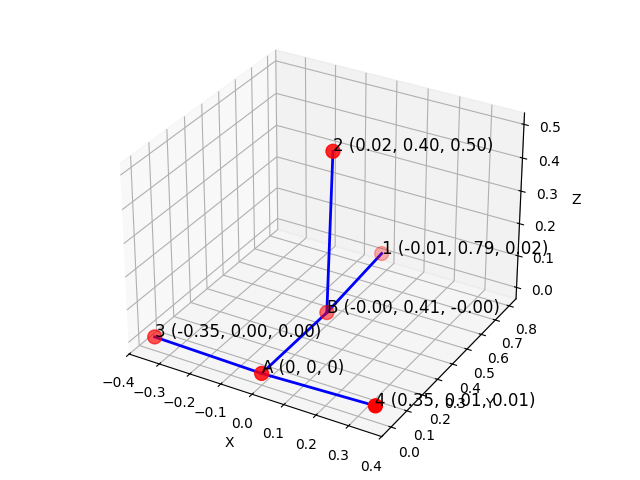

In [24]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS

distances = np.array([
    [0, 0.4, 0.8, 0.64, 0.35, 0.35],
    [0.4, 0, 0.375, 0.5, 0.53, 0.53],
    [0.8, 0.375, 0, 0.62, 0.86, 0.87],
    [0.64, 0.5, 0.62, 0, 0.73, 0.71],
    [0.35, 0.53, 0.86, 0.73, 0, 0.7],
    [0.35, 0.53, 0.87, 0.71, 0.7, 0]
])

mds = MDS(n_components=3, dissimilarity='precomputed', random_state=42) # 3 for 3D
coordinates = mds.fit_transform(distances)
print(f"Total Optimization Stress: {mds.stress_}")

print("Coordinates:")
print(coordinates)

og_coordinates = coordinates.copy() 

# ---------- Below is for normalization and rotation to make the coordinates more visually intuitive ----------

# Normalize the coordinates
coordinates -= coordinates[0]  # Set A as the origin (0, 0, 0)
coordinates[0] = [0, 0, 0]

print("Coordinates after normalization (A as origin):")
print(coordinates)

A3_vector = coordinates[4] - coordinates[0]  # Vector from A to 3
A4_vector = coordinates[5] - coordinates[0]  # Vector from A to 4

# Rotate around the z-axis
# Calculate the angle between A3_vector and the z-axis
x, y, z = A3_vector
angle_A3 = np.arctan2(x, y)
# Calculate the angle between A4_vector and the z-axis
x, y, z = A4_vector
angle_A4 = np.arctan2(x, y)
# Average the angles to get a single rotation angle
average_angle = -(angle_A3 + angle_A4) / 2
# Create a rotation matrix to rotate the coordinates around the z-axis
rotation_matrix = np.array([
    [np.cos(average_angle), -np.sin(average_angle), 0],
    [np.sin(average_angle), np.cos(average_angle), 0],
    [0, 0, 1]
])
coordinates = coordinates @ rotation_matrix.T

print("Rotated Coordinates (z-axis):")
print(coordinates)

# Rotate the coordinates around the y-axis
angle_A3_y = np.arctan2(np.sqrt(A3_vector[0]**2 + A3_vector[1]**2), A3_vector[2])  # Angle between A3 and x-axis
angle_A4_y = np.arctan2(np.sqrt(A4_vector[0]**2 + A4_vector[1]**2), A4_vector[2])  # Angle between A4 and x-axis
average_angle_y = (angle_A3_y - angle_A4_y) / 2
rotation_matrix_y = np.array([
    [np.cos(average_angle_y), 0, np.sin(average_angle_y)],
    [0, 1, 0],
    [-np.sin(average_angle_y), 0, np.cos(average_angle_y)]
])
coordinates = coordinates @ rotation_matrix_y.T
print("Rotated Coordinates (y-axis):")
print(coordinates)

# rotate around the x-axis to make point B on the xy plane
angle_B_x = - np.pi/2 - np.arctan2(np.sqrt(coordinates[1, 0]**2 + coordinates[1, 1]**2), coordinates[1, 2])  # Angle between B and x-axis
rotation_matrix_x = np.array([
    [1, 0, 0],
    [0, np.cos(angle_B_x), -np.sin(angle_B_x)],
    [0, np.sin(angle_B_x), np.cos(angle_B_x)]
])
coordinates = coordinates @ rotation_matrix_x.T
print("Rotated Coordinates (x-axis):")
print(coordinates)


# Create 3D plot
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(coordinates[:, 0], coordinates[:, 1], coordinates[:, 2], color='red', s=100)

# label the points and add the coordinates as text labels
ax.text(coordinates[0, 0], coordinates[0, 1], coordinates[0, 2], 'A (0, 0, 0)', fontsize=12)
ax.text(coordinates[1, 0], coordinates[1, 1], coordinates[1, 2], f'B ({coordinates[1, 0]:.2f}, {coordinates[1, 1]:.2f}, {coordinates[1, 2]:.2f})', fontsize=12)

# the rest of the points
for i, (x, y, z) in enumerate(coordinates):
    if i > 1:
        ax.text(x, y, z, f'{i-1} ({x:.2f}, {y:.2f}, {z:.2f})', fontsize=12)

# add lines in between the points: AB, A3, A4, B1, B2
ax.plot([coordinates[0, 0], coordinates[1, 0]], [coordinates[0, 1], coordinates[1, 1]], [coordinates[0, 2], coordinates[1, 2]], color='blue', linestyle='-', linewidth=2) # line AB
ax.plot([coordinates[0, 0], coordinates[4, 0]], [coordinates[0, 1], coordinates[4, 1]], [coordinates[0, 2], coordinates[4, 2]], color='blue', linestyle='-', linewidth=2) # line A3
ax.plot([coordinates[0, 0], coordinates[5, 0]], [coordinates[0, 1], coordinates[5, 1]], [coordinates[0, 2], coordinates[5, 2]], color='blue', linestyle='-', linewidth=2) # line A4
ax.plot([coordinates[1, 0], coordinates[2, 0]], [coordinates[1, 1], coordinates[2, 1]], [coordinates[1, 2], coordinates[2, 2]], color='blue', linestyle='-', linewidth=2) # line B1
ax.plot([coordinates[1, 0], coordinates[3, 0]], [coordinates[1, 1], coordinates[3, 1]], [coordinates[1, 2], coordinates[3, 2]], color='blue', linestyle='-', linewidth=2) # line B2  

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.tight_layout()

In [9]:
from scipy.spatial.distance import cdist

# actual point labels
Points = ['A', 'B', '1', '2', '3', '4']

# print out the coordinates of the points
print("Final Coordinates of the points:")
for i, (x, y, z) in enumerate(coordinates):
    print(f"Point {Points[i]}: ({x:.2f}, {y:.2f}, {z:.2f})")

# Calculate the distances between the points that MDS generated
generated_distances = cdist(coordinates, coordinates)

# print it in a matrix form
print("\nGenerated Distance Matrix:")
print(pd.DataFrame(generated_distances, index=Points, columns=Points).round(2))

# Compare the generated distances with the original distances
print("\nOriginal Distance Matrix:")
print(pd.DataFrame(distances, index=Points, columns=Points).round(2))

# Calculate the difference between the generated and original distances
difference = generated_distances - distances
print("\nDifference Matrix (Generated - Original):")
print(pd.DataFrame(difference, index=Points, columns=Points).round(2))

# Calculate the difference between the defined and original distances
defined_difference = defined_distances - distances
print("\nDifference Matrix (Defined - Original):")
print(pd.DataFrame(defined_difference, index=Points, columns=Points).round(2))

Final Coordinates of the points:
Point A: (0.00, 0.00, 0.00)
Point B: (-0.00, 0.41, -0.00)
Point 1: (-0.01, 0.79, 0.02)
Point 2: (0.02, 0.40, 0.50)
Point 3: (-0.35, 0.00, 0.00)
Point 4: (0.35, 0.01, 0.01)

Generated Distance Matrix:
      A     B     1     2     3     4
A  0.00  0.41  0.79  0.64  0.35  0.35
B  0.41  0.00  0.39  0.50  0.53  0.53
1  0.79  0.39  0.00  0.62  0.86  0.87
2  0.64  0.50  0.62  0.00  0.73  0.71
3  0.35  0.53  0.86  0.73  0.00  0.70
4  0.35  0.53  0.87  0.71  0.70  0.00

Original Distance Matrix:
      A     B     1     2     3     4
A  0.00  0.40  0.80  0.64  0.35  0.35
B  0.40  0.00  0.38  0.50  0.53  0.53
1  0.80  0.38  0.00  0.62  0.86  0.87
2  0.64  0.50  0.62  0.00  0.73  0.71
3  0.35  0.53  0.86  0.73  0.00  0.70
4  0.35  0.53  0.87  0.71  0.70  0.00

Difference Matrix (Generated - Original):
      A     B     1    2    3    4
A  0.00  0.01 -0.01 -0.0 -0.0 -0.0
B  0.01  0.00  0.01 -0.0  0.0  0.0
1 -0.01  0.01  0.00  0.0 -0.0 -0.0
2 -0.00 -0.00  0.00  0.0 

### Updating hydrophone configs
Update the hydrophone labels in the config file to the calculated coordinates

In [10]:
# update the hydrophone labels in the config files to the calculated coordinates from MDS
hydrophones_config['x'] = coordinates[2:6, 0]
hydrophones_config['y'] = coordinates[2:6, 1]
hydrophones_config['z'] = coordinates[2:6, 2]
hydrophones_config

,name,x,y,z,array_channel,audio_file_channel,data_path,file_name_root
0,Hydrophone 0,-0.014077,0.793069,0.016162,3,3,/Users/jasmineyeh/Desktop/WHOI/XAVarrays/lizar...,5147.
1,Hydrophone 1,0.019067,0.401157,0.497332,2,2,/Users/jasmineyeh/Desktop/WHOI/XAVarrays/lizar...,5147.
2,Hydrophone 2,-0.349627,0.004461,0.003800,1,1,/Users/jasmineyeh/Desktop/WHOI/XAVarrays/lizar...,5147.
3,Hydrophone 3,0.349473,0.006371,0.008471,0,0,/Users/jasmineyeh/Desktop/WHOI/XAVarrays/lizar...,5147.


## Loading Hydrophone Data
### Extract corresponding files from other hydrophone data

In [11]:
# Define file to process
infile = r'./data/5147.231123234849.wav'

# Look up data files for all channels
audio_files = tools.find_audio_files(infile, hydrophones_config)
audio_files

{'path': ['/Users/jasmineyeh/Desktop/WHOI/XAVarrays/lizard-island/data/5147.231123234849.wav',
  '/Users/jasmineyeh/Desktop/WHOI/XAVarrays/lizard-island/data/5147.231123234849.wav',
  '/Users/jasmineyeh/Desktop/WHOI/XAVarrays/lizard-island/data/5147.231123234849.wav',
  '/Users/jasmineyeh/Desktop/WHOI/XAVarrays/lizard-island/data/5147.231123234849.wav'],
 'channel': [3, 2, 1, 0]}

## Loading annotations from Raven
For this research, we annotated the data manually in raven, then loaded the annotations in through the `from_raven` function. Note that the channels in raven are 1-based, so we subtract all of the detections by 1. Futhermore, we have to insert deployment metadata since in localizaiton procedures we'll need some configs from the deployment info file.

In [12]:
from ecosound.core.annotation import Annotation
# load raven detections
raven_detections_file = r'./data/5147.231123234849.Table.1.selections_clean.txt'
detections = Annotation()
detections.from_raven(raven_detections_file, class_header=None, verbose=True)
detections.data["audio_channel"] -= 1 # convert to 0-indexed

# insert deployment metadata
detections.insert_metadata(deployment_info_file, channel=detection_config['AUDIO']['channel'])

detections.data

Name of annotated audio files could not be found
Duplicate entries removed: 0
Integrity test successful
22 annotations imported.


/Users/jasmineyeh/opt/anaconda3/envs/actlab/lib/python3.10/site-packages/ecosound/core/annotation.py:343: PerformanceWarning: Adding/subtracting object-dtype array to TimedeltaArray not vectorized.
  self.data["audio_file_start_date"]
/Users/jasmineyeh/opt/anaconda3/envs/actlab/lib/python3.10/site-packages/ecosound/core/annotation.py:347: PerformanceWarning: Adding/subtracting object-dtype array to TimedeltaArray not vectorized.
  self.data["audio_file_start_date"]


,uuid,from_detector,software_name,software_version,operator_name,UTC_offset,entry_date,audio_channel,audio_file_name,audio_file_dir,...,frequency_min,frequency_max,time_min_offset,time_max_offset,time_min_date,time_max_date,duration,label_class,label_subclass,confidence
0,e7711e08-5002-4ab7-bc15-09a07d1879e3,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,644.452,827.941,11.853374,11.920831,NaT,NaT,0.067457,NaN,NaN,NaN
1,1c413760-03e2-4e7e-8e2f-59a6917fa363,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,662.353,801.089,11.991355,12.046548,NaT,NaT,0.055192,NaN,NaN,NaN
2,c17f4fe5-d84f-4866-9bbb-8cd3dfb2b81c,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,617.600,711.582,12.104806,12.153866,NaT,NaT,0.049060,NaN,NaN,NaN
3,17c5aa8c-678d-4b68-9a68-402312f21133,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,639.976,756.336,13.806797,13.874255,NaT,NaT,0.067457,NaN,NaN,NaN
4,4d6774f2-731a-4c79-b1b1-cb065d20e00d,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,635.501,747.385,13.972374,14.033699,NaT,NaT,0.061325,NaN,NaN,NaN
5,b4290118-c154-4bfb-a67a-d6630a9458cd,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,631.026,751.860,14.095024,14.165548,NaT,NaT,0.070524,NaN,NaN,NaN
6,bf6f586e-1526-434b-8ff0-489f203aa116,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,768.166,1034.070,15.594235,15.997514,NaT,NaT,0.403278,NaN,NaN,NaN
7,9ccd07e7-8fa3-4afb-887b-5da8099e90cd,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,183.178,425.446,16.977523,17.190003,NaT,NaT,0.212480,NaN,NaN,NaN
8,a4986d51-7692-4f65-b0a0-4df248f32275,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,827.256,1158.158,17.693017,18.074613,NaT,NaT,0.381597,NaN,NaN,NaN
9,c4ffd2b4-db3c-4c94-870c-dc81df070459,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,856.801,1122.704,20.068779,20.172850,NaT,NaT,0.104072,NaN,NaN,NaN


In [13]:
# how to print the first row of the detections table
detections.data.iloc[0]

uuid                        b534c9f4-a832-4307-ba7c-e0f79eaf72bd
from_detector                                              False
software_name                                              raven
software_version                                             NaN
operator_name                                                NaN
UTC_offset                                                  10.0
entry_date                                                   NaT
audio_channel                                                  3
audio_file_name                                              NaN
audio_file_dir                                               NaN
audio_file_extension                                         NaN
audio_file_start_date                                        NaN
audio_sampling_frequency                                 96000.0
audio_bit_depth                                             16.0
mooring_platform_name                               mobile-array
recorder_type            

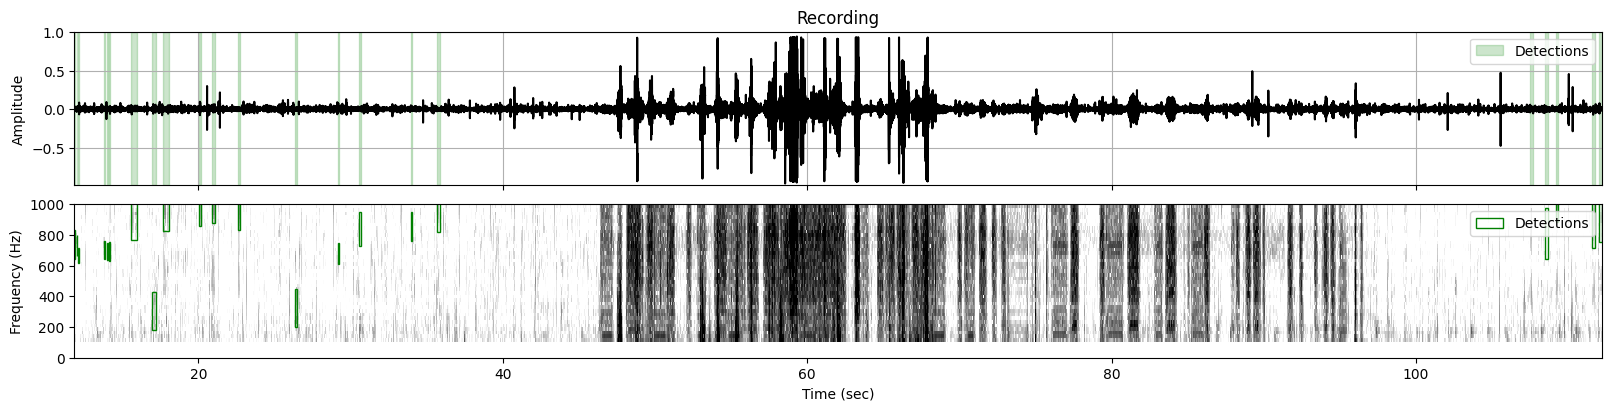

In [14]:
# plot detections
graph_detec = tools.plot_single_channel(audio_files['path'][detection_config['AUDIO']['channel']],
                                  detection_config['SPECTROGRAM']['frame_sec'],
                                  detection_config['SPECTROGRAM']['window_type'],
                                  detection_config['SPECTROGRAM']['nfft_sec'],
                                  detection_config['SPECTROGRAM']['step_sec'],
                                  detection_config['SPECTROGRAM']['fmin_hz'],
                                  detection_config['SPECTROGRAM']['fmax_hz'],
                                  detections=detections,
                                  verbose=False)
fig_graph_detec, ax_graph_detec = graph_detec.show(display=False)
fig_graph_detec

## Localization
### Localization Parameters

In [14]:
# localization configs
localization_config['TDOA']['upsample_res_sec'] = 0.00001
localization_config

{'ENVIRONMENT': {'sound_speed_mps': 1484},
 'TDOA': {'ref_channel': 3,
  'upsample_res_sec': 1e-05,
  'normalize': False,
  'min_corr_val': 0.5,
  'number_freq_bands': 4,
  'min_bandwidth_hz': 200,
  'energy_window_perc': 80},
 'GRIDSEARCH': {'x_limits_m': [-3, 3],
  'y_limits_m': [-3, 3],
  'z_limits_m': [-0.5, 4],
  'spacing_m': 0.02}}

In [15]:
# Creating a 3D grid of simulated TDOAs
tdoa_grid_file = r'./tdoa_grid.npz'
localization.GridSearch.create_tdoa_grid(localization_config['GRIDSEARCH']['x_limits_m'],
                                            localization_config['GRIDSEARCH']['y_limits_m'],
                                            localization_config['GRIDSEARCH']['z_limits_m'],
                                            localization_config['GRIDSEARCH']['spacing_m'],
                                            hydrophones_config,
                                            localization_config['TDOA']['ref_channel'],
                                            localization_config['ENVIRONMENT']['sound_speed_mps'],
                                            tdoa_grid_file)

# load grid of precomputed TDOAs
tdoa_grid = localization.GridSearch.load_tdoa_grid(tdoa_grid_file)

In [16]:
# Perform localization using grid search
localizations, PPDs = localization.GridSearch.run_localization(audio_files, detections, tdoa_grid, deployment_info_file, detection_config, hydrophones_config, localization_config, verbose=False)

progress: 100%|██████████| 22/22 [00:32<00:00,  1.47s/it]
/Users/jasmineyeh/Desktop/WHOI/XAVarrays/lizard-island/../localization/localization.py:843: RuntimeWarning: Credible interval could not reach the requested coverage. Requested 68%, achieved 67.8% around MAP=-0.5599999999999978. Interval=(-1.7199999999999989, 1.900000000000004). Lower side stopped because the requested probability mass was accumulated; upper side stopped because probability dropped below the cutoff (7.739842180350247e-06). This usually means the 1D marginal is clipped by the grid boundary or the probability mass falls below the stopping threshold before enough mass is accumulated.
  Py_CI = GridSearch.calc_credibility_interval(
/Users/jasmineyeh/Desktop/WHOI/XAVarrays/lizard-island/../localization/localization.py:843: RuntimeWarning: Credible interval could not reach the requested coverage. Requested 68%, achieved 67.5% around MAP=-0.45999999999999774. Interval=(-1.6199999999999988, 1.9400000000000048). Lower sid

In [17]:
localizations.data

,uuid,from_detector,software_name,software_version,operator_name,UTC_offset,entry_date,audio_channel,audio_file_name,audio_file_dir,...,x_err_low,x_err_high,x_err_span,y_err_low,y_err_high,y_err_span,z_err_low,z_err_high,z_err_span,tdoa_errors_std
0,e7711e08-5002-4ab7-bc15-09a07d1879e3,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,-1.18,2.26,3.44,-1.72,1.9,3.62,-0.5,3.08,3.58,0.000137
1,1c413760-03e2-4e7e-8e2f-59a6917fa363,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,-1.2,2.22,3.42,-1.62,1.94,3.56,-0.38,3.14,3.52,0.000137
2,c17f4fe5-d84f-4866-9bbb-8cd3dfb2b81c,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,-0.7,2.32,3.02,-1.9,1.42,3.32,-0.5,0.48,0.98,0.000137
3,17c5aa8c-678d-4b68-9a68-402312f21133,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,-1.42,2.04,3.46,-1.74,1.72,3.46,0.08,3.26,3.18,0.000137
4,4d6774f2-731a-4c79-b1b1-cb065d20e00d,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,-1.48,2.02,3.5,-1.64,1.84,3.48,0.1,3.28,3.18,0.000137
5,b4290118-c154-4bfb-a67a-d6630a9458cd,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,-1.26,2.06,3.32,-1.28,2.08,3.36,0.22,3.32,3.1,0.000137
6,bf6f586e-1526-434b-8ff0-489f203aa116,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,1.88,2.98,1.1,1.3,2.98,1.68,0.0,2.46,2.46,0.000137
7,9ccd07e7-8fa3-4afb-887b-5da8099e90cd,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,-2.24,2.98,5.22,-1.18,2.98,4.16,-0.5,3.06,3.56,0.000137
8,a4986d51-7692-4f65-b0a0-4df248f32275,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,1.52,2.8,1.28,0.82,2.5,1.68,-0.24,2.4,2.64,0.000137
9,c4ffd2b4-db3c-4c94-870c-dc81df070459,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,1.68,2.86,1.18,0.96,2.66,1.7,-0.32,2.14,2.46,0.000137


In [18]:
localizations.data.iloc[0]
localizations.to_csv('localization_results.csv')

In [19]:
# Filter localization results, leave only those in front of the camera (y > 0.7931)
new_localizations = localizations.filter("y > 0.7931") # inplace = True replaces the original data
new_localizations.data

,uuid,from_detector,software_name,software_version,operator_name,UTC_offset,entry_date,audio_channel,audio_file_name,audio_file_dir,...,x_err_low,x_err_high,x_err_span,y_err_low,y_err_high,y_err_span,z_err_low,z_err_high,z_err_span,tdoa_errors_std
0,bf6f586e-1526-434b-8ff0-489f203aa116,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,1.88,2.98,1.1,1.3,2.98,1.68,0.0,2.46,2.46,0.000137
1,a4986d51-7692-4f65-b0a0-4df248f32275,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,1.52,2.8,1.28,0.82,2.5,1.68,-0.24,2.4,2.64,0.000137
2,c4ffd2b4-db3c-4c94-870c-dc81df070459,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,1.68,2.86,1.18,0.96,2.66,1.7,-0.32,2.14,2.46,0.000137
3,1ffb0ea1-4c70-4a7c-8080-91c3f6124bdf,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,1.68,2.86,1.18,0.96,2.66,1.7,-0.32,2.14,2.46,0.000137
4,732647f8-bc09-4fce-b581-375dcfd75afb,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,1.22,2.68,1.46,0.8,2.38,1.58,-0.5,1.92,2.42,0.000137
5,993b6ab8-089f-4fdf-b765-42574c139fbb,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,2.0,2.98,0.98,1.0,2.98,1.98,-0.32,1.66,1.98,0.000137
6,b64d2e3b-bcdd-468f-bab2-c87ae63a732c,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,-0.82,2.38,3.2,-1.86,2.2,4.06,-0.5,2.36,2.86,0.000137
7,4796083b-21da-423a-8cd3-041305c375da,False,raven,NaN,NaN,10.0,NaT,3,NaN,NaN,...,-1.16,0.76,1.92,1.98,2.98,1.0,0.56,3.02,2.46,0.000137


In [21]:
new_localizations.to_csv('localization_results_filtered.csv')

### Localization Plotting
includes before filtering and after filtering

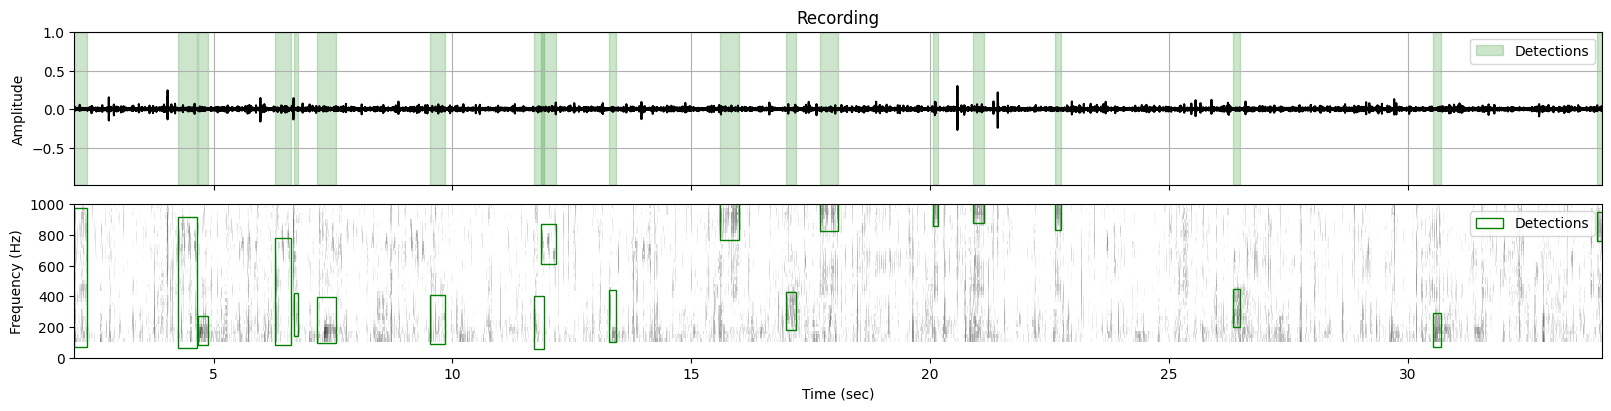

In [ ]:
# before filtering
# plot spectrogram with measurements filtered
graph_loc = tools.plot_single_channel(audio_files['path'][detection_config['AUDIO']['channel']],
                                      detection_config['SPECTROGRAM']['frame_sec'],
                                      detection_config['SPECTROGRAM']['window_type'],
                                      detection_config['SPECTROGRAM']['nfft_sec'],
                                      detection_config['SPECTROGRAM']['step_sec'],
                                      detection_config['SPECTROGRAM']['fmin_hz'],
                                      detection_config['SPECTROGRAM']['fmax_hz'],
                                      detections=localizations,
                                      verbose=False)
fig_graph_loc, ax_graph_loc = graph_loc.show(display=False)
fig_graph_loc

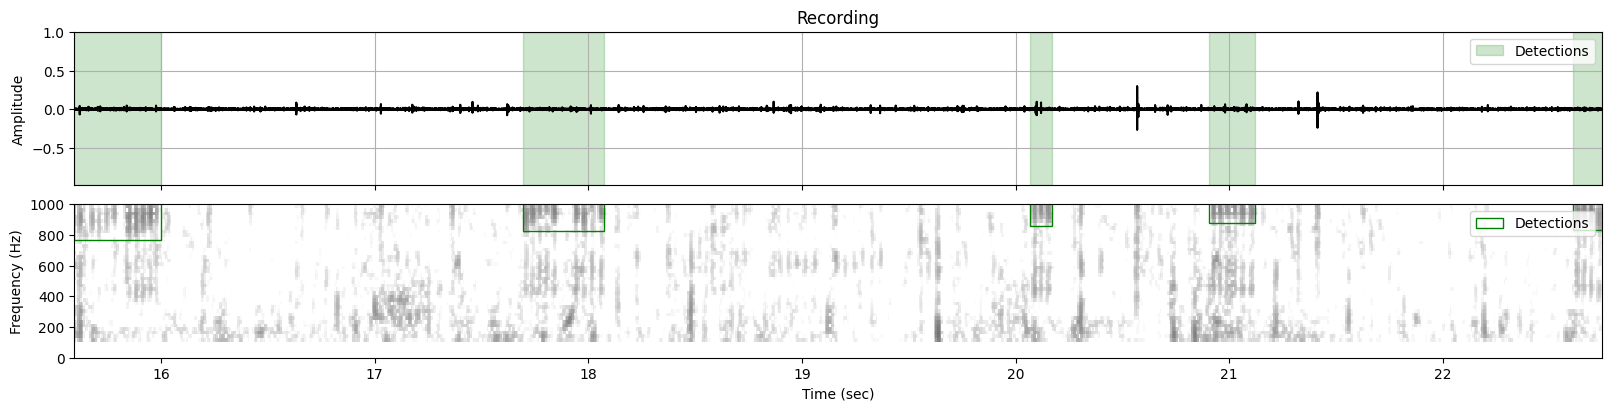

In [ ]:
# after filtering
# plot spectrogram with measurements filtered
graph_loc = tools.plot_single_channel(audio_files['path'][detection_config['AUDIO']['channel']],
                                      detection_config['SPECTROGRAM']['frame_sec'],
                                      detection_config['SPECTROGRAM']['window_type'],
                                      detection_config['SPECTROGRAM']['nfft_sec'],
                                      detection_config['SPECTROGRAM']['step_sec'],
                                      detection_config['SPECTROGRAM']['fmin_hz'],
                                      detection_config['SPECTROGRAM']['fmax_hz'],
                                      detections=new_localizations,
                                      verbose=False)
fig_graph_loc, ax_graph_loc = graph_loc.show(display=False)
fig_graph_loc

Plot the filtered localization results on a 3D grid

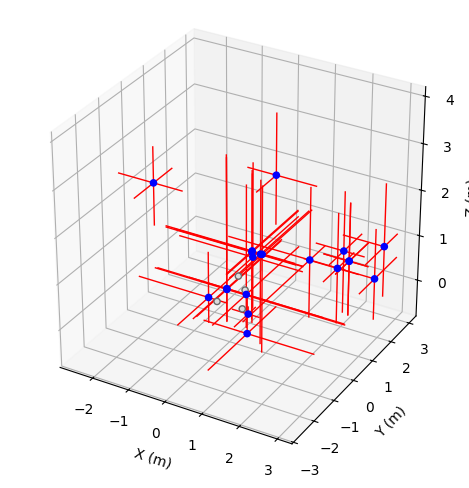

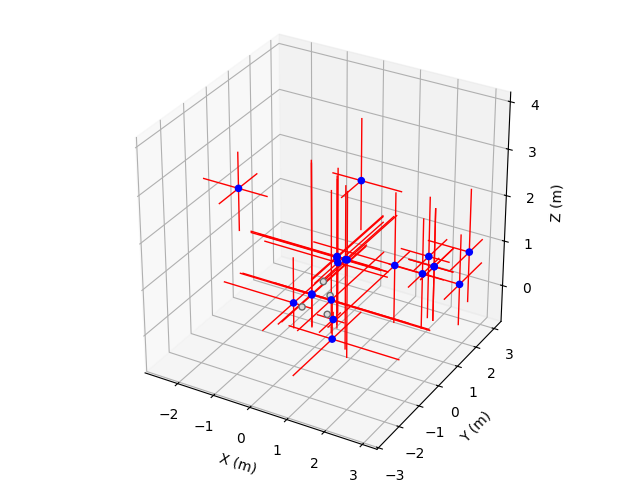

In [25]:
%matplotlib widget
# Plot localizations
fig_loc, fig_ax = localization.plot_localizations3D(localizations=localizations, hydrophones=hydrophones_config)
fig_loc

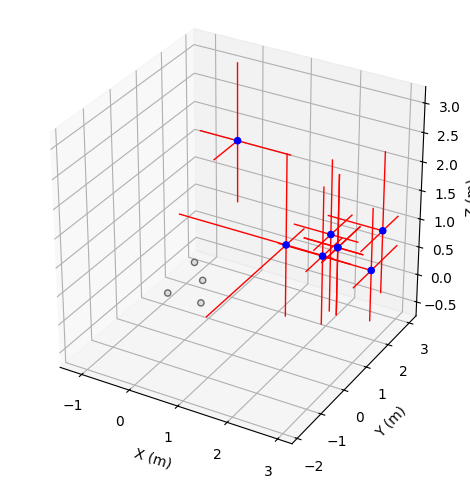

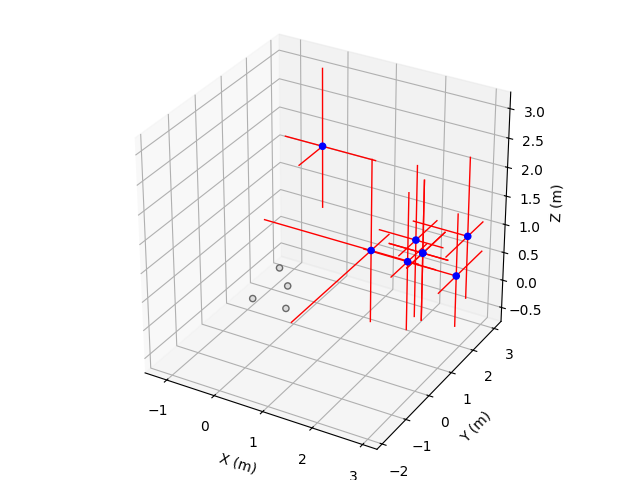

In [20]:
%matplotlib widget
# Plot localizations
fig_loc, fig_ax = localization.plot_localizations3D(localizations=new_localizations, hydrophones=hydrophones_config)
fig_loc

### Save localization results

In [ ]:
# save as csv:
localizations.to_csv('localization_results.csv')

# save as netcdf
localizations.to_netcdf('localization_results.nc')

## Others

In [28]:
# TODO:
# 1. change hydrophone coordinate calculation part into using tools.calc_hydrophones_distances(hydrophones_coords)
# 2. change plot_single_channel function to take x-axis limits as inputs, changing the time range of the graph.